# 23d - Classificatore Real + Augmented Tradizionale — Mammo-FM Fine-Tuned

Fine-tuning reale di **Mammo-FM** (EfficientNet-B5) su immagini reali + augmentation
tradizionale positiva (`data/real_augmented`, prodotta da `02_Data_Augmentation_Trad.ipynb`,
stesso path usato dai notebook 10/18/22a/22b). Nessuna immagine sintetica generativa: serve
da controllo per isolare l'effetto dell'augmentation tradizionale da quello delle immagini
sintetiche (confrontare con 23b/23c).

- **Train**: reali (`data/processed/train`) + augmented tradizionale positiva
- **Val**: SOLO reali (`data/processed/val`)
- **Test**: SOLO reali (`data/processed/test`), lo stesso test set reale di tutti
  gli altri notebook 23a-23d
- Risultati salvati in `experiments/03d_real_augmented/` (se `SMOKE_TEST=True`, in
  `experiments/03d_real_augmented_smoke/`: mai nella stessa cartella di un run reale).

**Importante**: se il checkpoint Mammo-FM non e' configurato/raggiungibile, il notebook si
ferma con un errore chiaro (vedi cella di configurazione), senza sostituire silenziosamente
il backbone con un modello generico.

**Licenza dei pesi Mammo-FM**: rilasciati con una "Custom Academic License for Model Weights"
(non commerciale, solo ricerca accademica; **nessun uso clinico/diagnostico**; nessuna
ridistribuzione dei pesi). Vedi https://huggingface.co/batmanLab/Mammo-FM/blob/main/LICENSE.
Il checkpoint viene scaricato nella cache locale di Hugging Face e non viene mai copiato nel
repository del progetto.

In [1]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-9a95e5e1-599d-6315-52fb-b6a602960eb8"  # RTX 3060
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

CUDA_VISIBLE_DEVICES: GPU-9a95e5e1-599d-6315-52fb-b6a602960eb8


In [2]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print(tf.config.list_physical_devices("GPU"))

for d in device_lib.list_local_devices():
    if d.device_type == "GPU":
        print(d.physical_device_desc)

2026-07-06 14:46:14.851291: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-06 14:46:14.851323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-06 14:46:14.852148: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-06 14:46:14.856741: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-06 14:46:15.464511: W tensorflow/compiler/tf2

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


2026-07-06 14:46:16.365410: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-06 14:46:16.405145: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-06 14:46:16.409322: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = Path("/content/drive/MyDrive/MammoDiffusion/").resolve()
    NOTEBOOKS_DIR = BASE / "notebooks"
else:
    print("Ambiente locale rilevato.")
    # Robusto sia se Jupyter e' avviato dalla root della repo sia da dentro notebooks/.
    _cwd = Path.cwd()
    if _cwd.name == "notebooks":
        BASE = _cwd.parent
        NOTEBOOKS_DIR = _cwd
    else:
        BASE = _cwd
        NOTEBOOKS_DIR = BASE / "notebooks"

sys.path.insert(0, str(NOTEBOOKS_DIR))
print("Percorso base:", BASE)
print("Cartella notebooks:", NOTEBOOKS_DIR)

Ambiente locale rilevato.
Percorso base: /home/fede/Documenti/MammoDiffusion
Cartella notebooks: /home/fede/Documenti/MammoDiffusion/notebooks


#### Import librerie

In [4]:
import json
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# NOTEBOOKS_DIR e' gia' stato inserito in sys.path dalla cella precedente (robusto sia da
# root della repo sia da dentro notebooks/), quindi qui basta importare direttamente.
from mammofm_utils import (
    DEFAULT_HF_REPO, DEFAULT_CHECKPOINT_NAME, DEFAULT_IMG_SIZE,
    DEFAULT_MAMMOFM_MEAN, DEFAULT_MAMMOFM_STD,
    MammoFMConfigError,
    BinaryFocalLoss,
    build_mammofm_model,
    make_mammofm_dataloader,
    freeze_backbone_all, unfreeze_head, unfreeze_last_n_blocks, unfreeze_all,
    count_trainable_params, compute_pos_weight,
    EarlyStopping, ModelCheckpoint, CSVLogger,
    fit_mammofm, predict_with_probs, optimal_threshold_youden,
    compute_full_metrics, bootstrap_balanced,
    plot_training_history, plot_roc_pr_confusion, plot_calibration_curve,
    seed_everything, save_json, save_training_history_csv, save_training_history_combined_csv,
    save_test_predictions, auto_interpret,
    load_real_split, load_augmented_positive,
    print_counts, source_table, check_duplicate_paths, check_no_split_overlap,
)

print("Import completato.")

Import completato.


#### Configurazione centrale

In [5]:
# --- Configurazione Mammo-FM ---------------------------------------------------
# Mammo-FM (batmanlab, arXiv:2512.00198) e' usato al posto di MammoDINO (GE HealthCare,
# arXiv:2510.11883) perche' quest'ultimo NON ha checkpoint pubblici disponibili, mentre
# Mammo-FM ha checkpoint pubblici su Hugging Face (batmanLab/Mammo-FM). Attenzione:
# Mammo-FM NON e' MammoDINO, e' un foundation model mammografico diverso (encoder
# EfficientNet-B5, non ViT/DINOv2).
#
# LICENZA: i pesi Mammo-FM sono rilasciati con una "Custom Academic License for Model
# Weights" (non commerciale, solo ricerca accademica; NESSUN uso clinico/diagnostico;
# nessuna ridistribuzione dei pesi). Questo notebook scarica il checkpoint nella cache
# locale di Hugging Face (~/.cache/huggingface/hub, fuori dal repository) e non lo copia
# mai altrove: non salvare ne' ridistribuire i pesi nel repository del progetto.
MAMMOFM_HF_REPO = DEFAULT_HF_REPO                    # "batmanLab/Mammo-FM"
MAMMOFM_CHECKPOINT_NAME = DEFAULT_CHECKPOINT_NAME    # "Mammo-FM_BatmanlabTrained_CLIP.tar"
USE_LOCAL_CHECKPOINT = False                         # True per usare un checkpoint gia' scaricato manualmente
MAMMOFM_LOCAL_CHECKPOINT_PATH = None                 # path locale al file .tar (usato solo se USE_LOCAL_CHECKPOINT=True)

# Preprocessing: l'encoder immagine EfficientNet-B5 del checkpoint Mammo-FM ufficiale
# ("tf_efficientnet_b5_ns-detect") ha il primo layer conv a 3 canali: le mammografie
# grayscale vengono quindi replicate su RGB (verificato ispezionando il checkpoint reale).
# Normalizzazione: media/std ufficiali di pre-training Mammo-CLIP/Mammo-FM (scalari, non
# statistiche ImageNet), applicate dopo una normalizzazione min-max per immagine in [0,1]
# (stesso preprocessing di `ImageClassificationDataset` nel repo ufficiale batmanlab/Mammo-CLIP).
IMG_SIZE = DEFAULT_IMG_SIZE          # 512x512: coerente con gli altri classificatori del progetto.
                                     # Risoluzione nativa di pre-training Mammo-FM: 1520x912 (non quadrata);
                                     # EfficientNet e' interamente convoluzionale quindi funziona anche a
                                     # 512x512, ma le prestazioni assolute potrebbero differire da quelle
                                     # riportate nel paper alla risoluzione nativa (scelta documentata).
MAMMOFM_MEAN = DEFAULT_MAMMOFM_MEAN  # 0.3089279 (scalare, non tripletta ImageNet)
MAMMOFM_STD = DEFAULT_MAMMOFM_STD    # 0.25053555408335154
USE_CLAHE_PREPROCESSING = False      # il pre-training ufficiale usa anche CLAHE (configs/transform/clahe.yaml):
                                     # disattivato di default per coerenza con gli altri classificatori del
                                     # progetto (nessuno dei quali usa CLAHE). Abilitabile per un esperimento
                                     # dedicato futuro.
DROPOUT = 0.1

# --- Esperimento --------------------------------------------------------------
SEED = 42
BATCH_SIZE = 8                  # EfficientNet-B5 e' piu' leggero di ViT-B/14: batch piu' alto rispetto
                                 # ai (deprecati) notebook MammoDINO. Ridurre se OOM.
GRAD_ACCUM_STEPS = 2             # batch effettivo = BATCH_SIZE * GRAD_ACCUM_STEPS
USE_AMP = True                   # mixed precision
GRAD_CLIP_NORM = 1.0
NUM_WORKERS = 2

FINE_TUNE_MODE = "partial"       # "partial": scongela solo le ultime stage MBConv + testa conv finale
                                  # (VRAM/stabilita'); "full": scongela tutto il backbone
UNFREEZE_LAST_N_BLOCKS = 2       # usato solo se FINE_TUNE_MODE == "partial". Nessun LoRA/adapter: sono pesi
                                  # reali del backbone EfficientNet-B5.

EPOCHS_PHASE1 = 25    # head training, backbone congelato
EPOCHS_PHASE2 = 30    # fine-tuning (parziale o completo)
LR_PHASE1 = 1e-3
LR_PHASE2 = 1e-5
EARLY_STOP_PATIENCE_PHASE1 = 7
EARLY_STOP_PATIENCE_PHASE2 = 5

SMOKE_TEST = False     # True = sottocampiona i dati e riduce le epoche per validare la pipeline end-to-end rapidamente

EXPERIMENT_NAME = "03d_real_augmented"
CONFIG_NAME = "Real+Augmented_Traditional"
TRAINING_MODE = "real_augmented"  # real_only | real_synthetic_sd_finetuned | real_synthetic_fromscratch | real_augmented

print(f"Esperimento: {EXPERIMENT_NAME} | Config: {CONFIG_NAME} | Training mode: {TRAINING_MODE}")
print(f"SMOKE_TEST attivo: {SMOKE_TEST}")

Esperimento: exp_mammofm_real_augmented | Config: Real+Augmented_Traditional | Training mode: real_augmented
SMOKE_TEST attivo: False


#### Setup seed, device e cartella esperimento

In [6]:
seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Se SMOKE_TEST e' attivo, usiamo una cartella esperimento separata (suffisso "_smoke") per
# non sovrascrivere/confondere mai i risultati di un run reale con quelli di un test rapido.
if SMOKE_TEST:
    EXPERIMENT_NAME = f"{EXPERIMENT_NAME}_smoke"
    print(f"SMOKE_TEST attivo: uso la cartella esperimento separata '{EXPERIMENT_NAME}' "
          "per non toccare i risultati di un run reale.")

OUTPUT_DIR = BASE / "experiments" / "classifiers" / "mammofm" / EXPERIMENT_NAME
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Cartella esperimento:", OUTPUT_DIR)

Device: cuda
Cartella esperimento: /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented


#### Verifica dataset e conteggi per classe/sorgente

In [7]:
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
PROCESSED_ZIP = BASE / "data" / "processed" / "processed.zip"


def processed_data_ready():
    required = [
        BASE / "data" / "processed" / "train" / "0",
        BASE / "data" / "processed" / "train" / "1",
        BASE / "data" / "processed" / "val" / "0",
        BASE / "data" / "processed" / "val" / "1",
        BASE / "data" / "processed" / "test" / "0",
        BASE / "data" / "processed" / "test" / "1",
    ]
    return all(p.is_dir() and any(p.iterdir()) for p in required)


if not processed_data_ready():
    print("Dataset preprocessato non trovato, scarico da Google Drive...")
    import zipfile
    import gdown

    PROCESSED_ZIP.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=str(PROCESSED_ZIP), quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, "r") as z:
        z.extractall(BASE / "data" / "processed")
    PROCESSED_ZIP.unlink(missing_ok=True)
    print("Dataset estratto in:", BASE / "data" / "processed")
else:
    print("Dataset reale preprocessato gia' presente.")

Dataset reale preprocessato gia' presente.


In [8]:
df_real_train = load_real_split(BASE, "train")
df_aug = load_augmented_positive(BASE, split_label="train")
df_val = load_real_split(BASE, "val")
df_test = load_real_split(BASE, "test")

df_train = pd.concat([df_real_train, df_aug], ignore_index=True)

print_counts("REAL train", df_real_train)
print_counts("AUG train (tradizionale)", df_aug)
print_counts("TRAIN combinato", df_train)
print_counts("VAL real", df_val)
print_counts("TEST real", df_test)
display(source_table(df_train))

check_duplicate_paths(df_train)
check_no_split_overlap({"train": df_train, "val": df_val, "test": df_test})

print("\nModalita' di training: REAL + AUGMENTED tradizionale (nessuna immagine sintetica generativa).")

REAL train               tot= 2041 | sano(0)= 1701 | malato(1)=  340
AUG train (tradizionale) tot= 1020 | sano(0)=    0 | malato(1)= 1020
TRAIN combinato          tot= 3061 | sano(0)= 1701 | malato(1)= 1360
VAL real                 tot=  437 | sano(0)=  364 | malato(1)=   73
TEST real                tot=  438 | sano(0)=  365 | malato(1)=   73


cancer,sano_0,malato_1,totale
source_detail,,,
real_train,1701,340,2041
traditional_positive_augmentation,0,1020,1020



Modalita' di training: REAL + AUGMENTED tradizionale (nessuna immagine sintetica generativa).


#### Dataset e DataLoader

In [9]:
if SMOKE_TEST:
    print("SMOKE_TEST attivo: sottocampiono i dati e riduco le epoche per validare la pipeline end-to-end.")

    def _subsample(df, n_per_class, seed=SEED):
        parts = []
        for label in (0, 1):
            sub = df[df["cancer"] == label]
            parts.append(sub.sample(n=min(n_per_class, len(sub)), random_state=seed))
        return pd.concat(parts, ignore_index=True).reset_index(drop=True)

    df_train = _subsample(df_train, 6)
    df_val = _subsample(df_val, 4)
    df_test = _subsample(df_test, 4)
    EPOCHS_PHASE1, EPOCHS_PHASE2 = 1, 1
    print_counts("TRAIN (smoke)", df_train)
    print_counts("VAL (smoke)", df_val)
    print_counts("TEST (smoke)", df_test)

train_loader = make_mammofm_dataloader(
    df_train, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, augment=False, use_clahe=USE_CLAHE_PREPROCESSING,
    seed=SEED, num_workers=NUM_WORKERS,
    drop_last=False,  # nessuna immagine di training persa nell'ultimo batch parziale (dataset piccolo/sbilanciato)
)
val_loader = make_mammofm_dataloader(
    df_val, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False, use_clahe=USE_CLAHE_PREPROCESSING, num_workers=NUM_WORKERS,
)
test_loader = make_mammofm_dataloader(
    df_test, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False, use_clahe=USE_CLAHE_PREPROCESSING, num_workers=NUM_WORKERS,
)
print(f"DataLoader pronti: train={len(df_train)} | val={len(df_val)} | test={len(df_test)} immagini.")

DataLoader pronti: train=3061 | val=437 | test=438 immagini.


#### Caricamento Mammo-FM

Il caricamento e' volutamente rigido: se `MAMMOFM_HF_REPO`/`MAMMOFM_CHECKPOINT_NAME` (o
`MAMMOFM_LOCAL_CHECKPOINT_PATH` con `USE_LOCAL_CHECKPOINT=True`) non sono configurati
correttamente, o se il checkpoint non e' raggiungibile/compatibile, il notebook si ferma con
un `MammoFMConfigError` invece di proseguire silenziosamente con un backbone generico
(DINOv2/RAD-DINO/ImageNet).

Il download avviene tramite `huggingface_hub.hf_hub_download` nella cache locale
(`~/.cache/huggingface/hub`), **mai** copiato nel repository del progetto (licenza dei pesi:
solo ricerca accademica non commerciale, nessun uso clinico, nessuna ridistribuzione).

In [10]:
try:
    model, resolved_mean, resolved_std, resolved_img_size, hidden_size, backend, source_desc = build_mammofm_model(
        hf_repo=MAMMOFM_HF_REPO,
        checkpoint_name=MAMMOFM_CHECKPOINT_NAME,
        use_local_checkpoint=USE_LOCAL_CHECKPOINT,
        local_checkpoint_path=MAMMOFM_LOCAL_CHECKPOINT_PATH,
        num_classes=1,
        dropout=DROPOUT,
    )
except MammoFMConfigError as exc:
    print("Impossibile caricare Mammo-FM. Il notebook si ferma qui deliberatamente:\n")
    print(exc)
    raise

model.to(DEVICE)
print(f"Backbone Mammo-FM caricato: backend={backend} | hidden_size={hidden_size} | img_size={resolved_img_size}")
print(f"Sorgente pesi: {source_desc}")

# Verifica di coerenza (difensiva): la normalizzazione/risoluzione di Mammo-FM e' fissa
# (non risolta da un image_processor dinamico), quindi qui non ci si aspetta un mismatch;
# se un checkpoint futuro dichiarasse valori diversi, ricostruiamo i DataLoader di conseguenza
# invece di procedere con un mismatch silenzioso.
if (resolved_mean != MAMMOFM_MEAN) or (resolved_std != MAMMOFM_STD) or (resolved_img_size != IMG_SIZE):
    warnings.warn(
        f"Normalizzazione/risoluzione risolta ({resolved_mean}, {resolved_std}, {resolved_img_size}) "
        f"diversa da quella di configurazione ({MAMMOFM_MEAN}, {MAMMOFM_STD}, {IMG_SIZE}). "
        "Ricostruisco i DataLoader con i valori risolti dal modello."
    )
    MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE = resolved_mean, resolved_std, resolved_img_size
    train_loader = make_mammofm_dataloader(
        df_train, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=True, augment=False, use_clahe=USE_CLAHE_PREPROCESSING,
        seed=SEED, num_workers=NUM_WORKERS, drop_last=False,
    )
    val_loader = make_mammofm_dataloader(
        df_val, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False, use_clahe=USE_CLAHE_PREPROCESSING, num_workers=NUM_WORKERS,
    )
    test_loader = make_mammofm_dataloader(
        df_test, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False, use_clahe=USE_CLAHE_PREPROCESSING, num_workers=NUM_WORKERS,
    )

/home/fede/Documenti/MammoDiffusion/notebooks/mammofm_utils.py:297: UserWarning: Checkpoint Mammo-FM: 2 tensori del backbone non trovati nel checkpoint (rimangono inizializzati casualmente), es. ['_fc.weight', '_fc.bias'] (atteso: il layer '_fc' finale, non incluso nel checkpoint ufficiale e non usato da questo helper, che estrae solo le feature pooled).
  warnings.warn(


Backbone Mammo-FM caricato: backend=efficientnet_pytorch | hidden_size=2048 | img_size=512
Sorgente pesi: huggingface:batmanLab/Mammo-FM/Mammo-FM_BatmanlabTrained_CLIP.tar (encoder=efficientnet-b5, config_name='tf_efficientnet_b5_ns-detect')


#### Costruzione testa classificativa e salvataggio configurazione di run

In [11]:
# Testa: Dropout + Linear(hidden_size -> 1) sopra l'encoder immagine Mammo-FM (EfficientNet-B5,
# feature pooled via global average pooling). Output: singolo logit + BCEWithLogitsLoss (Fase 1)
# / BinaryFocalLoss (Fase 2), coerente con gli altri classificatori del progetto.
print(model.classifier)

run_config = {
    "experiment_name": EXPERIMENT_NAME,
    "config": CONFIG_NAME,
    "training_mode": TRAINING_MODE,
    "date": date.today().isoformat(),
    "seed": SEED,
    "device": str(DEVICE),
    "smoke_test": SMOKE_TEST,
    "model": {
        "name": "Mammo-FM", "backend": backend, "source": source_desc,
        "hidden_size": hidden_size, "dropout": DROPOUT, "img_size": IMG_SIZE,
        "hf_repo": MAMMOFM_HF_REPO, "checkpoint_name": MAMMOFM_CHECKPOINT_NAME,
        "use_local_checkpoint": USE_LOCAL_CHECKPOINT,
        "use_clahe_preprocessing": USE_CLAHE_PREPROCESSING,
        "license_note": "Custom Academic License for Model Weights (non commerciale, solo ricerca "
                         "accademica, nessun uso clinico, nessuna ridistribuzione dei pesi).",
    },
    "data": {
        "batch_size": BATCH_SIZE, "grad_accum_steps": GRAD_ACCUM_STEPS, "num_workers": NUM_WORKERS,
        "n_train": int(len(df_train)), "n_val": int(len(df_val)), "n_test": int(len(df_test)),
        "source_counts_train": source_table(df_train).to_dict(orient="index"),
    },
    "phase1_head_training": {
        "optimizer": "AdamW", "learning_rate": LR_PHASE1,
        "loss": "BCEWithLogitsLoss(pos_weight=balanced)",
        "max_epochs": EPOCHS_PHASE1, "early_stopping_patience": EARLY_STOP_PATIENCE_PHASE1,
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "AdamW", "learning_rate": LR_PHASE2,
        "loss": "BinaryFocalLoss(alpha=0.75, gamma=2.0)",
        "max_epochs": EPOCHS_PHASE2, "fine_tune_mode": FINE_TUNE_MODE,
        "unfreeze_last_n_blocks": UNFREEZE_LAST_N_BLOCKS if FINE_TUNE_MODE == "partial" else "all",
        "early_stopping_patience": EARLY_STOP_PATIENCE_PHASE2,
        "use_amp": USE_AMP, "grad_clip_norm": GRAD_CLIP_NORM,
    },
}
save_json(run_config, OUTPUT_DIR / "run_config.json")
print("Configurazione di run salvata in:", OUTPUT_DIR / "run_config.json")

Linear(in_features=2048, out_features=1, bias=True)
Configurazione di run salvata in: /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/run_config.json


#### Training — Fase 1 (head training, backbone congelato)

In [12]:
freeze_backbone_all(model)
unfreeze_head(model)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 1): {trainable:,} / {total:,}")

pos_weight = compute_pos_weight(df_train["cancer"].values).to(DEVICE)
criterion_fase1 = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_fase1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_PHASE1)

early_stop_fase1 = EarlyStopping(patience=EARLY_STOP_PATIENCE_PHASE1, mode="max", restore_best_weights=True)
checkpoint_fase1 = ModelCheckpoint(str(OUTPUT_DIR / f"{EXPERIMENT_NAME}_fase1_best.pt"), mode="max")
csv_logger_fase1 = CSVLogger(str(OUTPUT_DIR / "training_log_fase1.csv"))

history_phase1 = fit_mammofm(
    model, train_loader, val_loader, optimizer_fase1, criterion_fase1,
    epochs=EPOCHS_PHASE1, device=DEVICE,
    early_stopping=early_stop_fase1, checkpoint=checkpoint_fase1, csv_logger=csv_logger_fase1,
    use_amp=USE_AMP, grad_clip_norm=GRAD_CLIP_NORM, accumulation_steps=GRAD_ACCUM_STEPS,
)

Parametri trainable (Fase 1): 2,049 / 28,344,882
Epoch 1/25 - loss: 0.6561 - auc: 0.7684 - val_loss: 0.5645 - val_auc: 0.6944
Epoch 2/25 - loss: 0.5624 - auc: 0.8382 - val_loss: 0.5008 - val_auc: 0.7139
Epoch 3/25 - loss: 0.5314 - auc: 0.8514 - val_loss: 0.4839 - val_auc: 0.7217
Epoch 4/25 - loss: 0.5139 - auc: 0.8610 - val_loss: 0.5658 - val_auc: 0.7250
Epoch 5/25 - loss: 0.5054 - auc: 0.8624 - val_loss: 0.4772 - val_auc: 0.7282
Epoch 6/25 - loss: 0.4869 - auc: 0.8737 - val_loss: 0.5347 - val_auc: 0.7323
Epoch 7/25 - loss: 0.4727 - auc: 0.8837 - val_loss: 0.5099 - val_auc: 0.7322
Epoch 8/25 - loss: 0.4689 - auc: 0.8842 - val_loss: 0.4781 - val_auc: 0.7234
Epoch 9/25 - loss: 0.4612 - auc: 0.8874 - val_loss: 0.4797 - val_auc: 0.7185
Epoch 10/25 - loss: 0.4599 - auc: 0.8852 - val_loss: 0.4692 - val_auc: 0.7269
Epoch 11/25 - loss: 0.4478 - auc: 0.8932 - val_loss: 0.4858 - val_auc: 0.7200
Epoch 12/25 - loss: 0.4488 - auc: 0.8918 - val_loss: 0.4863 - val_auc: 0.7296
Epoch 13/25 - loss: 0.44

#### Training — Fase 2 (fine-tuning reale: sblocco parziale o totale del backbone)

Nessun LoRA/adapter/linear-probing: in questa fase vengono aggiornati i pesi reali del
backbone EfficientNet-B5 (le ultime `UNFREEZE_LAST_N_BLOCKS` stage MBConv + la testa conv
finale `_conv_head`/`_bn1` se `FINE_TUNE_MODE="partial"`, oppure l'intero backbone se
`FINE_TUNE_MODE="full"`). Il congelamento progressivo serve solo a contenere VRAM/instabilita',
non sostituisce il fine-tuning vero e proprio.

In [13]:
if FINE_TUNE_MODE == "partial":
    unfreeze_last_n_blocks(model, n=UNFREEZE_LAST_N_BLOCKS)
    fine_tune_desc = f"ultime {UNFREEZE_LAST_N_BLOCKS} stage MBConv + testa conv finale"
elif FINE_TUNE_MODE == "full":
    unfreeze_all(model)
    fine_tune_desc = "tutto il backbone"
else:
    raise ValueError(f"FINE_TUNE_MODE non supportato: {FINE_TUNE_MODE}")

trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 2 - {fine_tune_desc}): {trainable:,} / {total:,}")

criterion_fase2 = BinaryFocalLoss(alpha=0.75, gamma=2.0)
optimizer_fase2 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_PHASE2)
lr_scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode="max", factor=0.5, patience=3, min_lr=1e-7,
)

early_stop_fase2 = EarlyStopping(patience=EARLY_STOP_PATIENCE_PHASE2, min_delta=1e-3, mode="max", restore_best_weights=True)
final_ckpt = OUTPUT_DIR / f"{EXPERIMENT_NAME}_final_best.pt"
checkpoint_fase2 = ModelCheckpoint(str(final_ckpt), mode="max")
csv_logger_fase2 = CSVLogger(str(OUTPUT_DIR / "training_log_fase2.csv"))

history_phase2 = fit_mammofm(
    model, train_loader, val_loader, optimizer_fase2, criterion_fase2,
    epochs=EPOCHS_PHASE2, device=DEVICE,
    early_stopping=early_stop_fase2, checkpoint=checkpoint_fase2, csv_logger=csv_logger_fase2,
    lr_scheduler=lr_scheduler_fase2,
    use_amp=USE_AMP, grad_clip_norm=GRAD_CLIP_NORM, accumulation_steps=GRAD_ACCUM_STEPS,
)
print("\nTraining completato. Best model:", final_ckpt)

Parametri trainable (Fase 2 - ultime 2 stage MBConv + testa conv finale): 9,007,361 / 28,344,882
Epoch 1/30 - loss: 0.0630 - auc: 0.8667 - val_loss: 0.0579 - val_auc: 0.7276
Epoch 2/30 - loss: 0.0553 - auc: 0.8701 - val_loss: 0.0561 - val_auc: 0.7251
Epoch 3/30 - loss: 0.0491 - auc: 0.8845 - val_loss: 0.0536 - val_auc: 0.7269
Epoch 4/30 - loss: 0.0476 - auc: 0.8858 - val_loss: 0.0530 - val_auc: 0.7275
Epoch 5/30 - loss: 0.0452 - auc: 0.8959 - val_loss: 0.0524 - val_auc: 0.7229
Epoch 6/30 - loss: 0.0457 - auc: 0.8881 - val_loss: 0.0527 - val_auc: 0.7190
Early stopping all'epoca 6 (best val_auc=0.7276)

Training completato. Best model: /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/exp_mammofm_real_augmented_final_best.pt


#### Curve di training (loss / AUC)

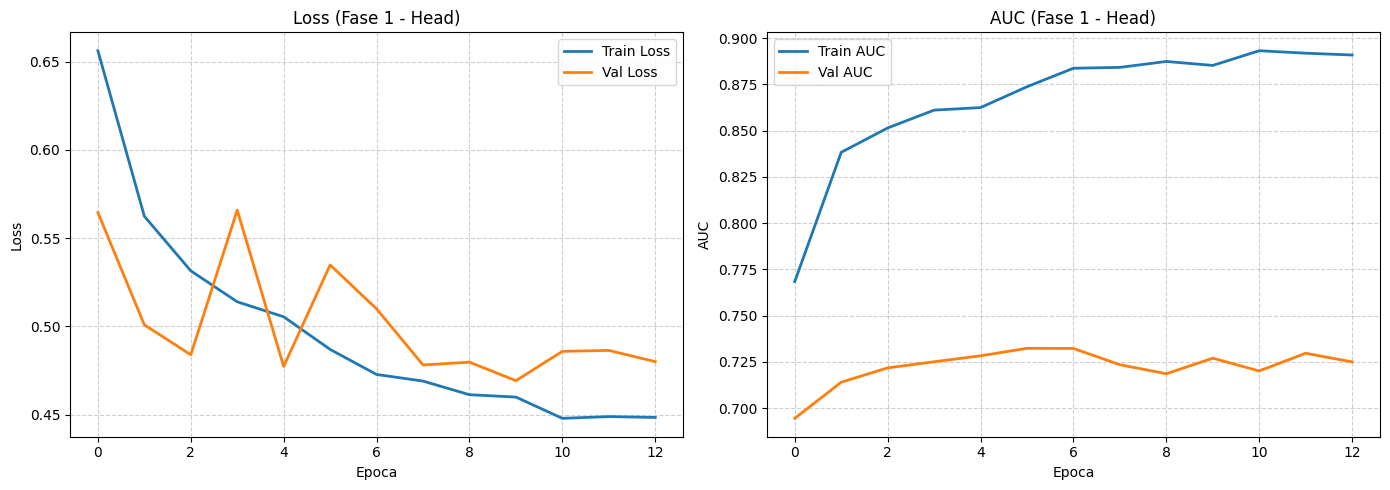

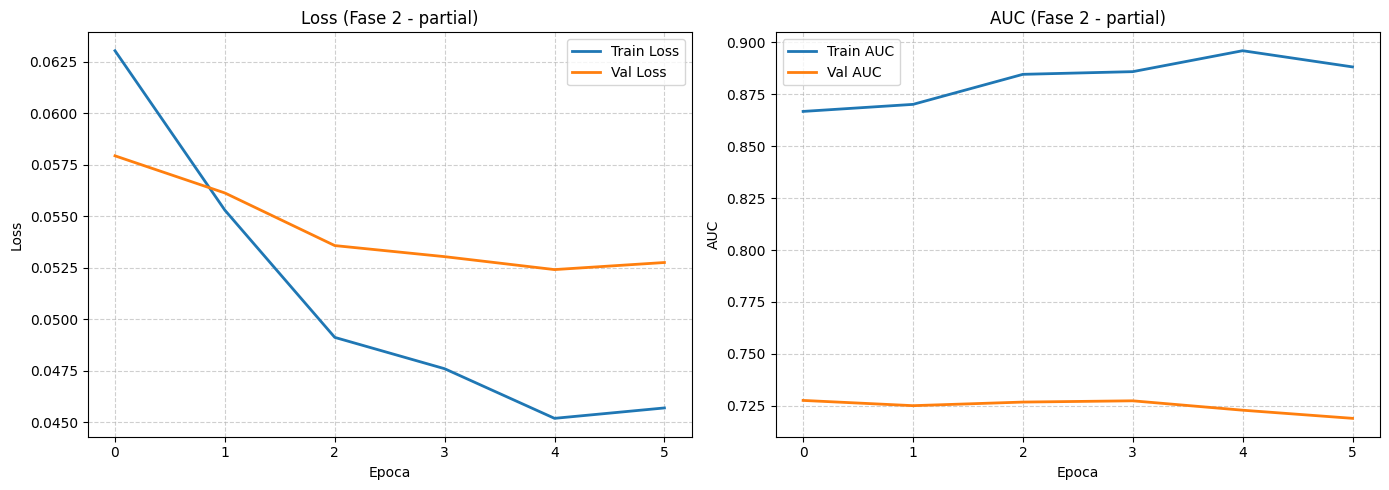

Storico di training combinato salvato in: /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/training_history_combined.csv


In [14]:
plot_training_history(history_phase1, "(Fase 1 - Head)", FIGURES_DIR / "training_history_fase1.png")
plot_training_history(history_phase2, f"(Fase 2 - {FINE_TUNE_MODE})", FIGURES_DIR / "training_history_fase2.png")

save_training_history_csv(history_phase1, OUTPUT_DIR / "training_history_fase1.csv")
save_training_history_csv(history_phase2, OUTPUT_DIR / "training_history_fase2.csv")

# CSV combinato (fase 1 + fase 2, colonna "phase"): non sostituisce i due file separati sopra.
save_training_history_combined_csv(history_phase1, history_phase2, OUTPUT_DIR / "training_history_combined.csv")
print("Storico di training combinato salvato in:", OUTPUT_DIR / "training_history_combined.csv")

#### Validazione ed early stopping — soglia di Youden

Soglia ottimale (Youden) sul validation: 0.4227
Val ROC-AUC: 0.7276 | Val PR-AUC: 0.3937 | Val Balanced Acc: 0.6707


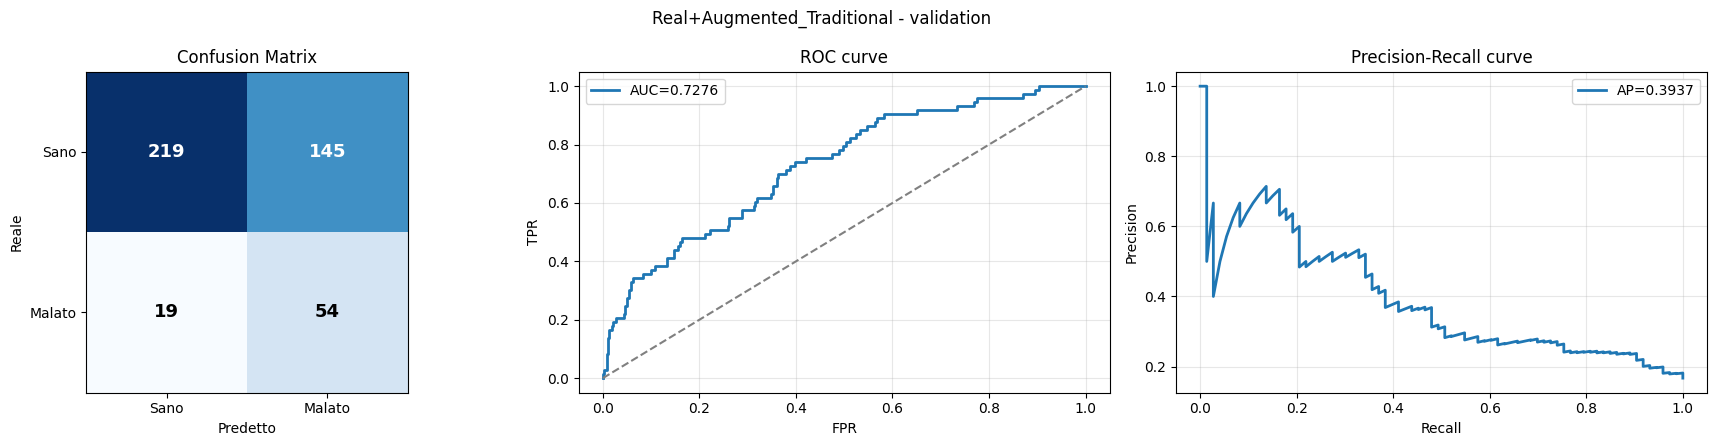

In [15]:
model.load_state_dict(torch.load(final_ckpt, map_location=DEVICE))

y_val_true, y_val_prob = predict_with_probs(
    model, df_val, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE, BATCH_SIZE, DEVICE,
)
val_threshold = optimal_threshold_youden(y_val_true, y_val_prob)
val_metrics, y_val_pred = compute_full_metrics(y_val_true, y_val_prob, val_threshold, "validation", EXPERIMENT_NAME, CONFIG_NAME)
val_metrics["fine_tune_mode"] = FINE_TUNE_MODE
val_metrics["checkpoint"] = str(final_ckpt)
save_json(val_metrics, OUTPUT_DIR / "val_metrics.json")

print(f"Soglia ottimale (Youden) sul validation: {val_threshold:.4f}")
print(f"Val ROC-AUC: {val_metrics['roc_auc']:.4f} | Val PR-AUC: {val_metrics['pr_auc_average_precision']:.4f} "
      f"| Val Balanced Acc: {val_metrics['balanced_accuracy']:.4f}")

plot_roc_pr_confusion(y_val_true, y_val_prob, y_val_pred, f"{CONFIG_NAME} - validation", FIGURES_DIR / "val_confusion_roc_pr.png")

#### Test finale

{
  "roc_auc": 0.617,
  "pr_auc_average_precision": 0.2664,
  "accuracy": 0.5959,
  "balanced_accuracy": 0.5932,
  "f1": 0.327,
  "precision": 0.2263,
  "recall_sensitivity": 0.589,
  "specificity": 0.5973,
  "brier_score": 0.2078
}


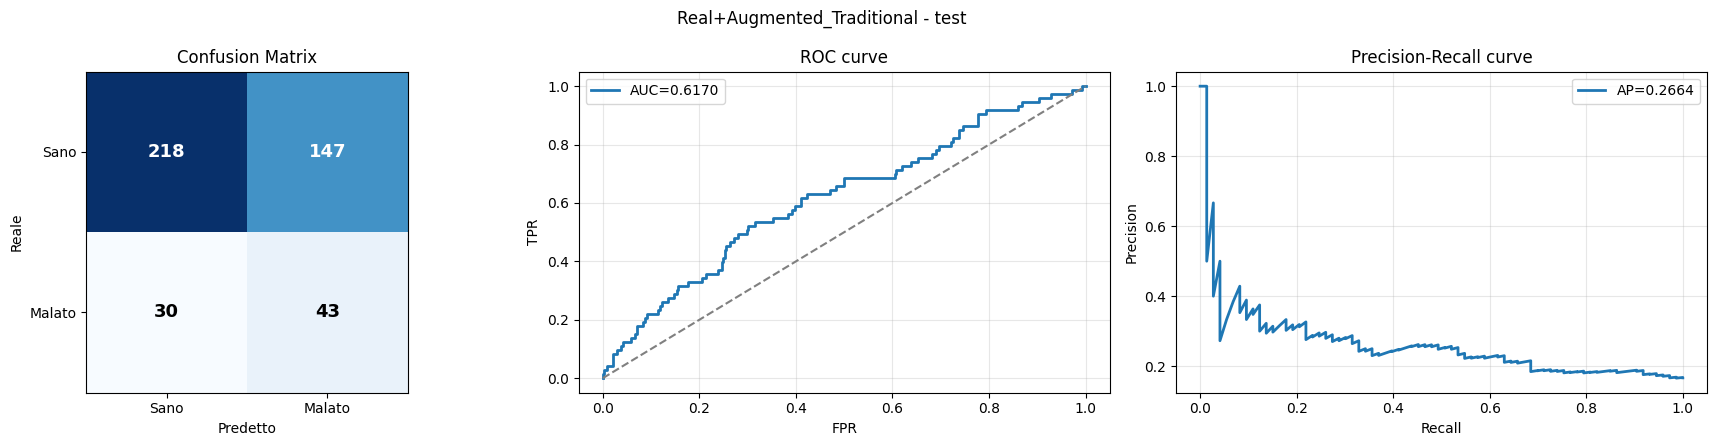

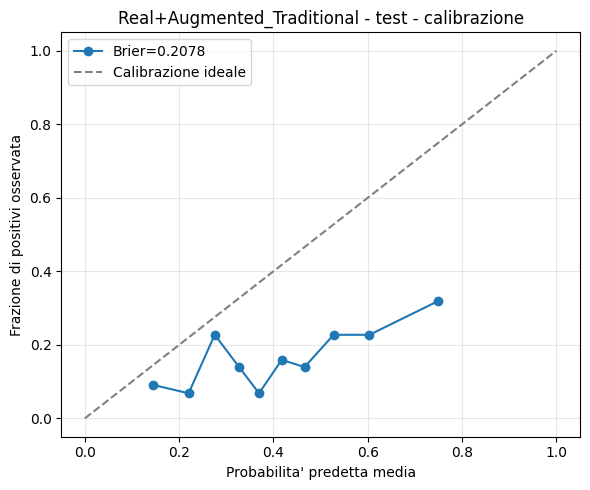

In [16]:
y_test_true, y_test_prob = predict_with_probs(
    model, df_test, "processed_path", "cancer", MAMMOFM_MEAN, MAMMOFM_STD, IMG_SIZE, BATCH_SIZE, DEVICE,
)
test_metrics, y_test_pred = compute_full_metrics(y_test_true, y_test_prob, val_threshold, "test", EXPERIMENT_NAME, CONFIG_NAME)
test_metrics["fine_tune_mode"] = FINE_TUNE_MODE
test_metrics["checkpoint"] = str(final_ckpt)
test_metrics["training_mode"] = TRAINING_MODE
save_json(test_metrics, OUTPUT_DIR / "metrics.json")

print(json.dumps({
    k: test_metrics[k] for k in [
        "roc_auc", "pr_auc_average_precision", "accuracy", "balanced_accuracy",
        "f1", "precision", "recall_sensitivity", "specificity", "brier_score",
    ]
}, indent=2))

plot_roc_pr_confusion(y_test_true, y_test_prob, y_test_pred, f"{CONFIG_NAME} - test", FIGURES_DIR / "test_confusion_roc_pr.png")
plot_calibration_curve(y_test_true, y_test_prob, f"{CONFIG_NAME} - test - calibrazione", FIGURES_DIR / "test_calibration.png")

#### Bootstrap bilanciato sul test set (robustezza delle metriche)

{
  "Accuracy": {
    "mean": 0.5938698630136987,
    "std": 0.04038191143168358
  },
  "Precision": {
    "mean": 0.5949442163064785,
    "std": 0.04196361096593264
  },
  "Recall": {
    "mean": 0.5921643835616438,
    "std": 0.05526173414442653
  },
  "F1": {
    "mean": 0.5926086958300788,
    "std": 0.0429441234070156
  },
  "ROC_AUC": {
    "mean": 0.617378307374742,
    "std": 0.04619465113297804
  }
}


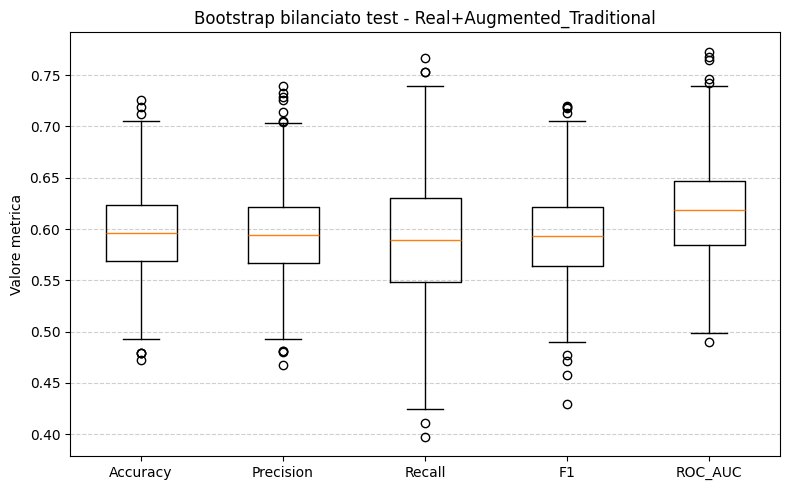

In [17]:
n_rounds = 200 if SMOKE_TEST else 1000
boot = bootstrap_balanced(y_test_true, y_test_prob, val_threshold, n_rounds=n_rounds, seed=SEED)
boot_summary = {k: {"mean": float(np.mean(v)), "std": float(np.std(v))} for k, v in boot.items()}
save_json(boot_summary, OUTPUT_DIR / "bootstrap_balanced_test.json")
print(json.dumps(boot_summary, indent=2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(boot.values()))
ax.set_xticklabels(list(boot.keys()))
ax.set_title(f"Bootstrap bilanciato test - {CONFIG_NAME}")
ax.set_ylabel("Valore metrica")
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bootstrap_test.png", dpi=150, bbox_inches="tight")
plt.show()

#### Salvataggio predizioni di test

In [18]:
test_predictions_df = save_test_predictions(
    df_test, y_test_true, y_test_prob, val_threshold,
    path_col="processed_path", source_col="source_detail",
    save_path=OUTPUT_DIR / "test_predictions.csv", split_name="test",
)
print("Predizioni di test salvate in:", OUTPUT_DIR / "test_predictions.csv")
test_predictions_df.head()

Predizioni di test salvate in: /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/test_predictions.csv


,path,label,probability,prediction,split,source
0,/home/fede/Documenti/MammoDiffusion/data/proce...,0,0.322060,0,test,real_test
1,/home/fede/Documenti/MammoDiffusion/data/proce...,0,0.590529,1,test,real_test
2,/home/fede/Documenti/MammoDiffusion/data/proce...,0,0.347807,0,test,real_test
3,/home/fede/Documenti/MammoDiffusion/data/proce...,0,0.534880,1,test,real_test
4,/home/fede/Documenti/MammoDiffusion/data/proce...,0,0.455539,1,test,real_test


#### Riepilogo artefatti salvati

In [19]:
print(f"Esperimento '{EXPERIMENT_NAME}' ({CONFIG_NAME}) completato.")
print(f"Training mode: {TRAINING_MODE} | SMOKE_TEST: {SMOKE_TEST}")
print("Artefatti salvati in:", OUTPUT_DIR)
for name in [
    "run_config.json", "metrics.json", "val_metrics.json", "test_predictions.csv",
    "training_history_fase1.csv", "training_history_fase2.csv", "training_history_combined.csv",
    "bootstrap_balanced_test.json",
    f"{EXPERIMENT_NAME}_final_best.pt",
]:
    p = OUTPUT_DIR / name
    print(f"  [{'OK' if p.exists() else 'MANCANTE'}] {p}")
print("Figure salvate in:", FIGURES_DIR)
print()
print("Promemoria licenza Mammo-FM: solo ricerca accademica non commerciale, nessun uso")
print("clinico/diagnostico, nessuna ridistribuzione dei pesi. I pesi restano nella cache")
print("locale di Hugging Face e NON vengono salvati in questo repository.")

Esperimento 'exp_mammofm_real_augmented' (Real+Augmented_Traditional) completato.
Training mode: real_augmented | SMOKE_TEST: False
Artefatti salvati in: /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented
  [OK] /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/run_config.json
  [OK] /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/metrics.json
  [OK] /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/val_metrics.json
  [OK] /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/test_predictions.csv
  [OK] /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/training_history_fase1.csv
  [OK] /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/training_history_fase2.csv
  [OK] /home/fede/Documenti/MammoDiffusion/experiments/exp_mammofm_real_augmented/training_history_combined.csv
  [OK] /home/fede/Documenti/MammoDiffusion/exp